In [2]:
from typing import Any, Dict, List, Tuple
import argparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [12]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.shape

(7043, 21)

In [14]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Try to import XGBoost; if not installed, we will skip it
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    XGBClassifier = None
    xgb_available = False

import matplotlib.pyplot as plt
import seaborn as sns

# Configure plots
sns.set(style="whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries imported. XGBoost available:", xgb_available)

Libraries imported. XGBoost available: True


In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Try to import XGBoost; if not installed, we will skip it
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    XGBClassifier = None
    xgb_available = False

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported. XGBoost available:", xgb_available)

Libraries imported. XGBoost available: True


In [8]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<Axes: xlabel='Churn', ylabel='count'>

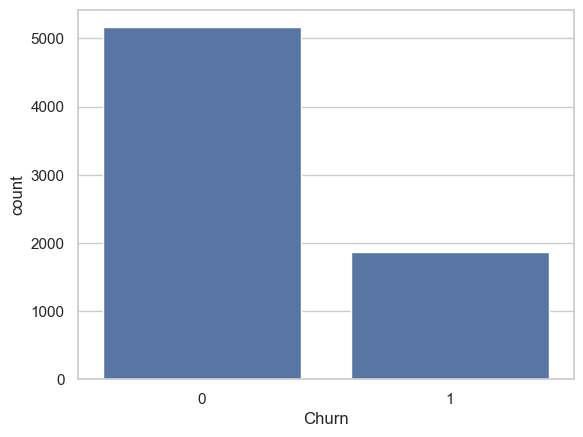

In [31]:
sns.countplot(x='Churn', data=df)

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

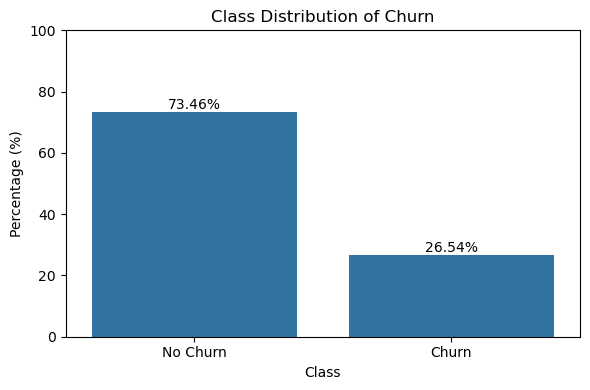

In [21]:
churn_dist = df['Churn'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
sns.barplot(x=churn_dist.index, y=churn_dist.values)
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.ylabel('Percentage (%)')
plt.xlabel('Class')
plt.title('Class Distribution of Churn')
plt.ylim(0, 100)

for i, v in enumerate(churn_dist.values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.tight_layout()
plt.show()

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

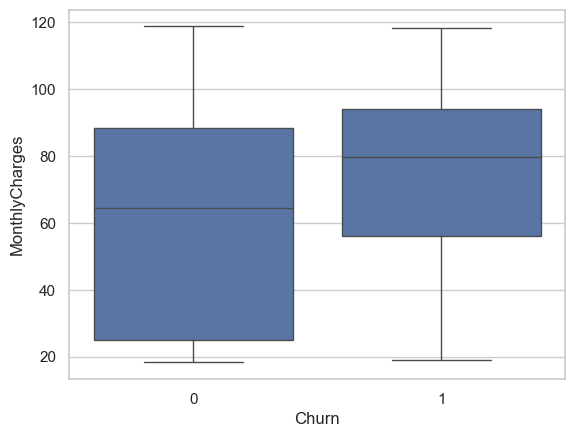

In [32]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

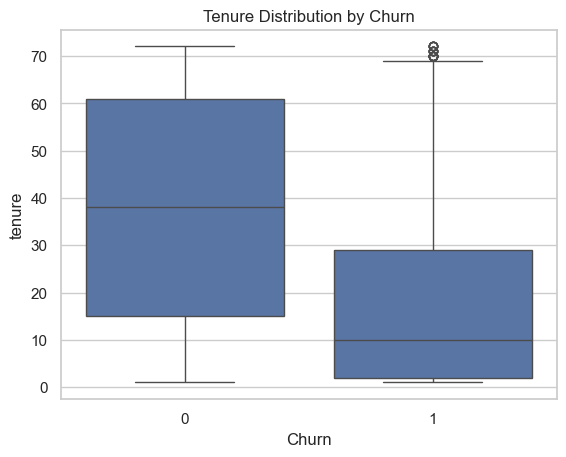

In [53]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure Distribution by Churn")
plt.show()

<Axes: xlabel='Contract', ylabel='count'>

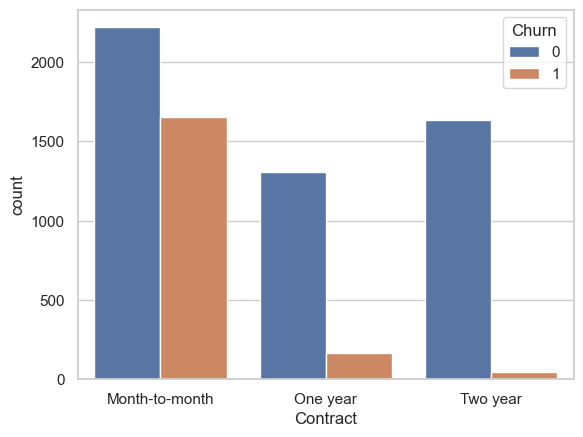

In [33]:
sns.countplot(x='Contract', hue='Churn', data=df)

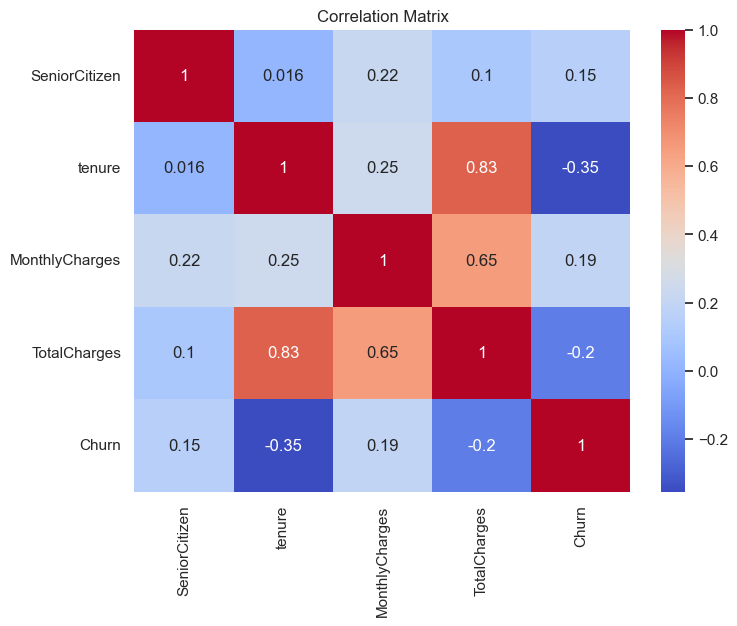

In [55]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
)

from sklearn.inspection import permutation_importance

In [6]:
RANDOM_STATE = 42
N_ITER_SEARCH = 12

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.head())
print(df.shape)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [5]:
data = df.copy()

data.columns = [c.strip() for c in data.columns]

for col in data.select_dtypes(include=["object"]).columns:
    data[col] = data[col].astype(str).str.strip()

data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})

data = data.drop(columns=["customerID"])

print(data.head())
print(data.info())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

C:\Users\user\AppData\Local\Temp\ipykernel_23324\3421249663.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include=["object"]).columns:


In [6]:
print(type(data))
print(data.shape)
print(data.columns)

<class 'pandas.DataFrame'>
(7043, 20)
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [7]:
# 1) Average charge per month
tenure_safe = data["tenure"].replace(0, 1)
data["AvgChargesPerMonth"] = data["TotalCharges"] / tenure_safe

# 2) Number of active services
service_cols = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

def service_is_active(x):
    return int(str(x) not in ["No", "No internet service", "No phone service", "nan"])

data["NumServices"] = data[service_cols].map(service_is_active).sum(axis=1)

# 3) Long-term customer flag
data["IsLongTermCustomer"] = (data["tenure"] >= 24).astype(int)

# 4) High monthly charges flag
monthly_threshold = data["MonthlyCharges"].median()
data["HighMonthlyCharges"] = (data["MonthlyCharges"] >= monthly_threshold).astype(int)

# 5) Electronic check flag
data["UsesElectronicCheck"] = (data["PaymentMethod"] == "Electronic check").astype(int)

print(data.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

  PaperlessBilling              PaymentMethod MonthlyCharges TotalCharges  \
0              Yes           Electronic check          29.85        29.85   
1   

In [8]:
print(data.columns)
print(data[[
    "AvgChargesPerMonth",
    "NumServices",
    "IsLongTermCustomer",
    "HighMonthlyCharges",
    "UsesElectronicCheck"
]].head())

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'AvgChargesPerMonth',
       'NumServices', 'IsLongTermCustomer', 'HighMonthlyCharges',
       'UsesElectronicCheck'],
      dtype='str')
   AvgChargesPerMonth  NumServices  IsLongTermCustomer  HighMonthlyCharges  \
0           29.850000            2                   0                   0   
1           55.573529            4                   1                   0   
2           54.075000            4                   0                   0   
3           40.905556            4                   1                   0   
4           75.825000            2                   0                   1   

   UsesElectronicCheck  
0                    1  

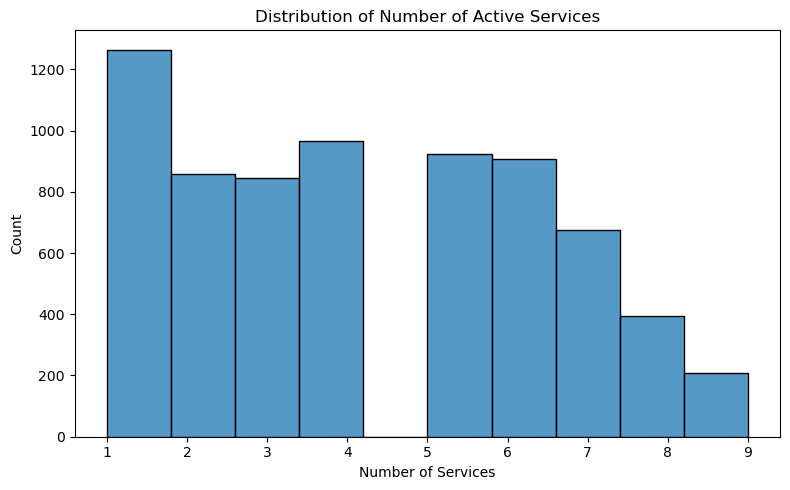

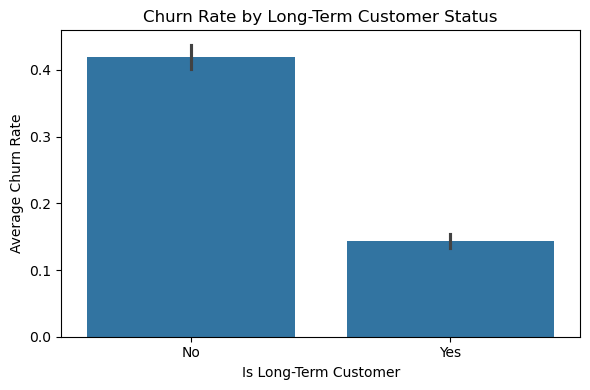

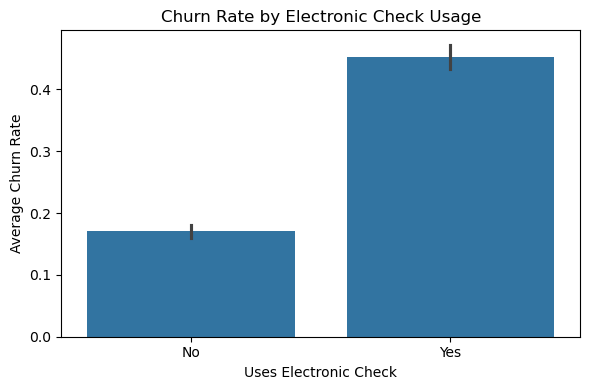

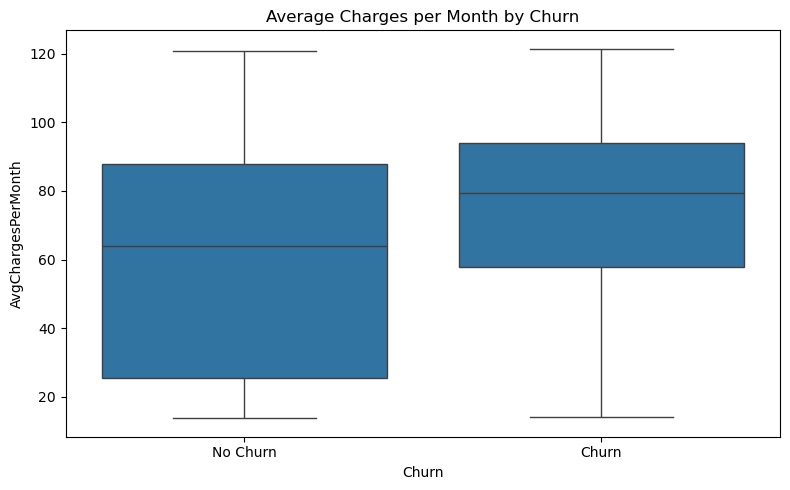

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x="NumServices", bins=10, kde=False)
plt.title("Distribution of Number of Active Services")
plt.xlabel("Number of Services")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(x="IsLongTermCustomer", y="Churn", data=data)
plt.xticks([0, 1], ["No", "Yes"])
plt.title("Churn Rate by Long-Term Customer Status")
plt.ylabel("Average Churn Rate")
plt.xlabel("Is Long-Term Customer")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(x="UsesElectronicCheck", y="Churn", data=data)
plt.xticks([0, 1], ["No", "Yes"])
plt.title("Churn Rate by Electronic Check Usage")
plt.ylabel("Average Churn Rate")
plt.xlabel("Uses Electronic Check")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="AvgChargesPerMonth", data=data)
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.title("Average Charges per Month by Churn")
plt.tight_layout()
plt.show()

In [9]:
X = data.drop(columns=["Churn"])
y = data["Churn"].astype(int)

print(X.shape)
print(y.value_counts())
print(X.head())

(7043, 24)
Churn
0    5174
1    1869
Name: count, dtype: int64
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

         Contract PaperlessBilling              PaymentMethod MonthlyCharges  \
0  Month-to-mon

In [10]:
print(type(X))
print(type(y))
print(X.shape)
print(y.shape)

<class 'pandas.DataFrame'>
<class 'pandas.Series'>
(7043, 24)
(7043,)


In [11]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor defined.")

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargesPerMonth', 'NumServices', 'IsLongTermCustomer', 'HighMonthlyCharges', 'UsesElectronicCheck']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Preprocessor defined.


In [12]:
print(type(preprocessor))
print(numeric_features)
print(categorical_features)

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargesPerMonth', 'NumServices', 'IsLongTermCustomer', 'HighMonthlyCharges', 'UsesElectronicCheck']
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 5634
Test size: 1409


In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 24)
(1409, 24)
(5634,)
(1409,)


In [15]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_and_parameters = {
    "LogisticRegression": {
        "model": LogisticRegression(
            max_iter=4000,
            solver="liblinear",
            class_weight="balanced",
            random_state=42
        ),
        "use_smote": False,
        "params": {
            "model__C": [0.01, 0.1, 1, 10]
        }
    },
    "SVM": {
        "model": SVC(
            probability=True,
            class_weight="balanced",
            random_state=42
        ),
        "use_smote": True,
        "params": {
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", 0.01, 0.1],
            "model__kernel": ["rbf"]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ),
        "use_smote": False,
        "params": {
            "model__n_estimators": [200, 300],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2]
        }
    }
}

results = []
best_estimators = {}

for model_name, config in models_and_parameters.items():
    print(f"\nRunning GridSearchCV for: {model_name}")

    steps = [("preprocess", preprocessor)]
    if config["use_smote"]:
        steps.append(("smote", SMOTE(random_state=42)))
    steps.append(("model", config["model"]))

    pipeline = ImbPipeline(steps=steps)

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_estimators[model_name] = best_model

    y_pred = best_model.predict(X_test)

    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    results.append({
        "Model": model_name,
        "Best_Params": grid.best_params_,
        "Best_CV_F1": grid.best_score_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc
    })

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
results_df


Running GridSearchCV for: LogisticRegression
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Running GridSearchCV for: SVM
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Running GridSearchCV for: RandomForest
Fitting 5 folds for each of 24 candidates, totalling 120 fits


,Model,Best_Params,Best_CV_F1,Accuracy,Precision,Recall,F1,ROC_AUC
2,RandomForest,"{'model__max_depth': 10, 'model__min_samples_l...",0.632392,0.770759,0.552577,0.716578,0.623981,0.839265
1,SVM,"{'model__C': 10, 'model__gamma': 0.01, 'model_...",0.630806,0.756565,0.529190,0.751337,0.620994,0.825811
0,LogisticRegression,{'model__C': 1},0.631331,0.737402,0.503436,0.783422,0.612971,0.840562


In [16]:
print(type(results_df))
print(results_df.head())
print(results_df.iloc[0])

<class 'pandas.DataFrame'>
                Model                                        Best_Params  \
2        RandomForest  {'model__max_depth': 10, 'model__min_samples_l...   
1                 SVM  {'model__C': 10, 'model__gamma': 0.01, 'model_...   
0  LogisticRegression                                    {'model__C': 1}   

   Best_CV_F1  Accuracy  Precision    Recall        F1   ROC_AUC  
2    0.632392  0.770759   0.552577  0.716578  0.623981  0.839265  
1    0.630806  0.756565   0.529190  0.751337  0.620994  0.825811  
0    0.631331  0.737402   0.503436  0.783422  0.612971  0.840562  
Model                                               RandomForest
Best_Params    {'model__max_depth': 10, 'model__min_samples_l...
Best_CV_F1                                              0.632392
Accuracy                                                0.770759
Precision                                               0.552577
Recall                                                  0.716578
F1        

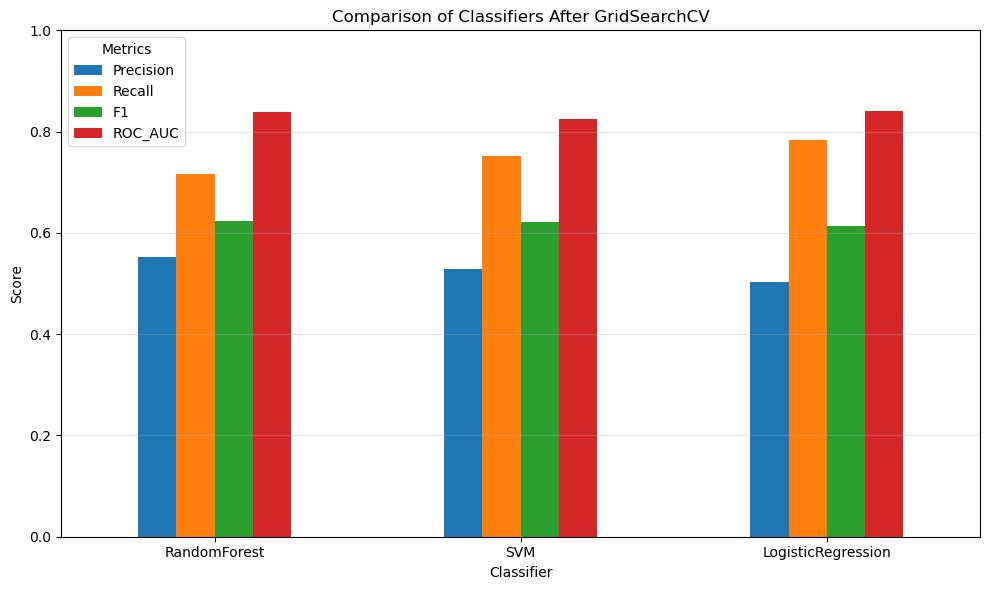

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = results_df.copy()

metrics_to_plot = ["Precision", "Recall", "F1", "ROC_AUC"]
plot_df = plot_df[["Model"] + metrics_to_plot].set_index("Model")

ax = plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Comparison of Classifiers After GridSearchCV")
plt.ylabel("Score")
plt.xlabel("Classifier")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metrics")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

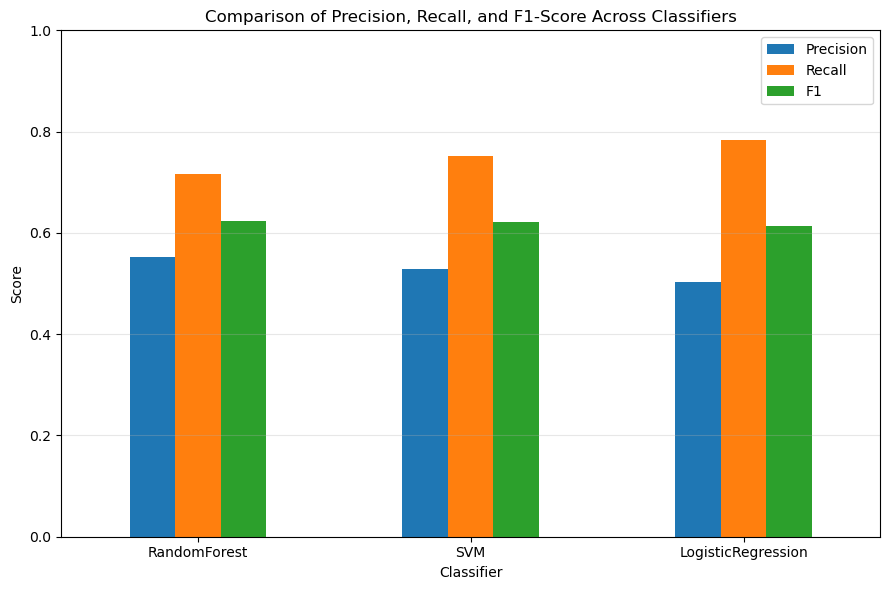

In [23]:
plot_df = results_df[["Model", "Precision", "Recall", "F1"]].set_index("Model")

ax = plot_df.plot(kind="bar", figsize=(9, 6))
plt.title("Comparison of Precision, Recall, and F1-Score Across Classifiers")
plt.ylabel("Score")
plt.xlabel("Classifier")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
tenure_safe = data["tenure"].replace(0, 1)
data["AvgChargesPerMonth"] = data["TotalCharges"] / tenure_safe

service_cols = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

def service_is_active(x):
    return int(str(x) not in ["No", "No internet service", "No phone service", "nan"])

data["NumServices"] = data[service_cols].map(service_is_active).sum(axis=1)

data["IsLongTermCustomer"] = (data["tenure"] >= 24).astype(int)

monthly_threshold = data["MonthlyCharges"].median()
data["HighMonthlyCharges"] = (data["MonthlyCharges"] >= monthly_threshold).astype(int)

data["UsesElectronicCheck"] = (data["PaymentMethod"] == "Electronic check").astype(int)

print(data.head())
print(data.columns)

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [8]:
data = df.copy()

data.columns = [c.strip() for c in data.columns]

for col in data.select_dtypes(include=["object", "string"]).columns:
    data[col] = data[col].astype(str).str.strip()

data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})
data = data.drop(columns=["customerID"])

print(data.head())
print(data.shape)
print(data.dtypes)

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [9]:
# 1) Average charge per month
tenure_safe = data["tenure"].replace(0, 1)
data["AvgChargesPerMonth"] = data["TotalCharges"] / tenure_safe

# 2) Number of active services
service_cols = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

def service_is_active(x):
    return int(str(x) not in ["No", "No internet service", "No phone service", "nan"])

data["NumServices"] = data[service_cols].map(service_is_active).sum(axis=1)

# 3) Long-term customer flag
data["IsLongTermCustomer"] = (data["tenure"] >= 24).astype(int)

# 4) High monthly charges flag
monthly_threshold = data["MonthlyCharges"].median()
data["HighMonthlyCharges"] = (data["MonthlyCharges"] >= monthly_threshold).astype(int)

# 5) Electronic check flag
data["UsesElectronicCheck"] = (data["PaymentMethod"] == "Electronic check").astype(int)

print(data.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

  PaperlessBilling              PaymentMethod MonthlyCharges TotalCharges  \
0              Yes           Electronic check          29.85        29.85   
1   

In [15]:
X = data.drop(columns=["Churn"])
y = data["Churn"].astype(int)

print(X.shape)
print(y.value_counts())
print(X.head())

(7043, 24)
Churn
0    5174
1    1869
Name: count, dtype: int64
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

         Contract PaperlessBilling              PaymentMethod MonthlyCharges  \
0  Month-to-mon

In [16]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor defined.")

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargesPerMonth', 'NumServices', 'IsLongTermCustomer', 'HighMonthlyCharges', 'UsesElectronicCheck']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Preprocessor defined.


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 5634
Test size: 1409


In [18]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_and_parameters = {
    "LogisticRegression": {
        "model": LogisticRegression(
            max_iter=4000,
            solver="liblinear",
            class_weight="balanced",
            random_state=42
        ),
        "use_smote": False,
        "params": {
            "model__C": [0.01, 0.1, 1, 10]
        }
    },
    "SVM": {
        "model": SVC(
            probability=True,
            class_weight="balanced",
            random_state=42
        ),
        "use_smote": True,
        "params": {
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", 0.01, 0.1],
            "model__kernel": ["rbf"]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ),
        "use_smote": False,
        "params": {
            "model__n_estimators": [200, 300],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2]
        }
    }
}

results = []
best_estimators = {}

for model_name, config in models_and_parameters.items():
    print(f"\nRunning GridSearchCV for: {model_name}")

    steps = [("preprocess", preprocessor)]
    if config["use_smote"]:
        steps.append(("smote", SMOTE(random_state=42)))
    steps.append(("model", config["model"]))

    pipeline = ImbPipeline(steps=steps)

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_estimators[model_name] = best_model

    y_pred = best_model.predict(X_test)

    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    results.append({
        "Model": model_name,
        "Best_Params": grid.best_params_,
        "Best_CV_F1": grid.best_score_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc
    })

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
results_df


Running GridSearchCV for: LogisticRegression
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Running GridSearchCV for: SVM
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Running GridSearchCV for: RandomForest
Fitting 5 folds for each of 24 candidates, totalling 120 fits


,Model,Best_Params,Best_CV_F1,Accuracy,Precision,Recall,F1,ROC_AUC
2,RandomForest,"{'model__max_depth': 10, 'model__min_samples_l...",0.632392,0.770759,0.552577,0.716578,0.623981,0.839265
1,SVM,"{'model__C': 10, 'model__gamma': 0.01, 'model_...",0.630806,0.756565,0.529190,0.751337,0.620994,0.825811
0,LogisticRegression,{'model__C': 1},0.631331,0.737402,0.503436,0.783422,0.612971,0.840562


In [19]:
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ]
)

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 9
Categorical columns: 15


In [20]:
print(results_df)
print("\nBest model:")
print(results_df.iloc[0])

                Model                                        Best_Params  \
2        RandomForest  {'model__max_depth': 10, 'model__min_samples_l...   
1                 SVM  {'model__C': 10, 'model__gamma': 0.01, 'model_...   
0  LogisticRegression                                    {'model__C': 1}   

   Best_CV_F1  Accuracy  Precision    Recall        F1   ROC_AUC  
2    0.632392  0.770759   0.552577  0.716578  0.623981  0.839265  
1    0.630806  0.756565   0.529190  0.751337  0.620994  0.825811  
0    0.631331  0.737402   0.503436  0.783422  0.612971  0.840562  

Best model:
Model                                               RandomForest
Best_Params    {'model__max_depth': 10, 'model__min_samples_l...
Best_CV_F1                                              0.632392
Accuracy                                                0.770759
Precision                                               0.552577
Recall                                                  0.716578
F1                      

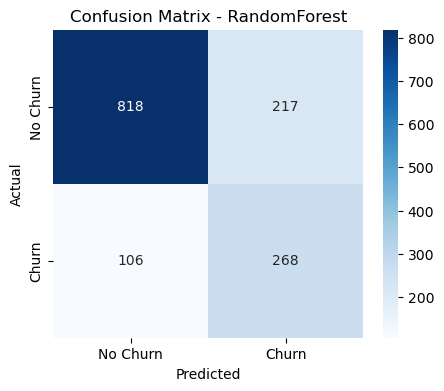

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

best_model_name = results_df.iloc[0]["Model"]
best_model = best_estimators[best_model_name]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Train size:", len(X_train))
print("Validation size:", len(X_valid))
print("Test size:", len(X_test))

Train size: 4225
Validation size: 1409
Test size: 1409


In [30]:
def find_best_threshold(y_true, y_proba, objective="f1"):
    thresholds = np.arange(0.20, 0.81, 0.02)
    best_threshold = 0.50
    best_score = -1
    best_metrics = {}

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if objective == "precision":
            score = prec
        elif objective == "recall":
            score = rec
        else:
            score = f1

        if score > best_score:
            best_score = score
            best_threshold = threshold
            best_metrics = {
                "Precision_valid": prec,
                "Recall_valid": rec,
                "F1_valid": f1,
            }

    return best_threshold, best_metrics

In [25]:
RANDOM_STATE = 42
N_ITER_SEARCH = 10

In [27]:
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    XGBClassifier = None
    xgb_available = False

print("XGBoost available:", xgb_available)

XGBoost available: True


In [28]:
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos

model_configs = {
"LogisticRegression": {
    "model": LogisticRegression(
        max_iter=4000,
        solver="liblinear",
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "use_smote": False,
    "params": {
        "model__C": np.logspace(-2, 2, 10),
    },
},
    "SVM": {
        "model": SVC(
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "use_smote": True,
        "params": {
            "model__C": [0.1, 0.5, 1, 2, 5, 10],
            "model__gamma": ["scale", 0.01, 0.05, 0.1, 0.5],
            "model__kernel": ["rbf"],
        },
    },
    "RandomForest": {
        "model": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
        ),
        "use_smote": False,
        "params": {
            "model__n_estimators": [200, 300, 500, 700],
            "model__max_depth": [None, 5, 8, 12, 16],
            "model__min_samples_split": [2, 5, 10, 20],
            "model__min_samples_leaf": [1, 2, 4, 8],
        },
    },
}

if xgb_available:
    model_configs["XGBoost"] = {
        "model": XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
        ),
        "use_smote": False,
        "params": {
            "model__n_estimators": [200, 300, 500, 700],
            "model__max_depth": [3, 4, 5, 6, 8],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "model__min_child_weight": [1, 3, 5],
        },
    }

print(model_configs.keys())

dict_keys(['LogisticRegression', 'SVM', 'RandomForest', 'XGBoost'])


In [41]:
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos

model_configs = {
    "LogisticRegression": {
        "model": LogisticRegression(
            max_iter=4000,
            solver="liblinear",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "use_smote": False,
        "params": {
            "model__C": np.logspace(-2, 2, 10),
        },
    },
    "SVM": {
        "model": SVC(
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "use_smote": True,
        "params": {
            "model__C": [0.1, 0.5, 1, 2, 5, 10],
            "model__gamma": ["scale", 0.01, 0.05, 0.1, 0.5],
            "model__kernel": ["rbf"],
        },
    },
    "RandomForest": {
        "model": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
        ),
        "use_smote": False,
        "params": {
            "model__n_estimators": [200, 300, 500, 700],
            "model__max_depth": [None, 5, 8, 12, 16],
            "model__min_samples_split": [2, 5, 10, 20],
            "model__min_samples_leaf": [1, 2, 4, 8],
        },
    },
}

if xgb_available:
    model_configs["XGBoost"] = {
        "model": XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
        ),
        "use_smote": False,
        "params": {
            "model__n_estimators": [200, 300, 500, 700],
            "model__max_depth": [3, 4, 5, 6, 8],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "model__subsample": [0.7, 0.8, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "model__min_child_weight": [1, 3, 5],
        },
    }

In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
artifacts = {}
trained_pipelines = {}

threshold_objective = "f1"   # change to "recall" or "precision" if needed

for model_name, config in model_configs.items():
    print(f"\nTraining and tuning: {model_name}")

    steps = [("preprocess", preprocessor)]
    if config["use_smote"]:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))
    steps.append(("model", config["model"]))

    pipeline = ImbPipeline(steps=steps)

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config["params"],
        n_iter=N_ITER_SEARCH,
        scoring="f1",
        cv=cv,
        verbose=1,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )

    search.fit(X_train, y_train)
    best_pipeline = search.best_estimator_
    trained_pipelines[model_name] = best_pipeline

    # Threshold tuning on validation set
    y_valid_proba = best_pipeline.predict_proba(X_valid)[:, 1]
    best_threshold, valid_metrics = find_best_threshold(
        y_valid, y_valid_proba, objective=threshold_objective
    )

    # Final evaluation on test set
    y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= best_threshold).astype(int)

    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    roc_auc = auc(fpr, tpr)
    cm = confusion_matrix(y_test, y_test_pred)

    results.append({
        "Model": model_name,
        "BestCV_F1": search.best_score_,
        "Threshold": best_threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "BestParams": search.best_params_,
    })

    artifacts[model_name] = {
        "confusion_matrix": cm,
        "fpr": fpr,
        "tpr": tpr,
    }

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
results_df


Training and tuning: LogisticRegression
Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\user\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 10 is smaller than n_iter=12. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Training and tuning: SVM
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Training and tuning: RandomForest
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Training and tuning: XGBoost
Fitting 5 folds for each of 12 candidates, totalling 60 fits


,Model,BestCV_F1,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,BestParams
3,XGBoost,0.631359,0.58,0.780696,0.573696,0.676471,0.620859,0.836764,"{'model__subsample': 0.9, 'model__n_estimators..."
1,SVM,0.620997,0.54,0.761533,0.537402,0.729947,0.619048,0.832775,"{'model__kernel': 'rbf', 'model__gamma': 'scal..."
0,LogisticRegression,0.633631,0.62,0.770050,0.552966,0.697861,0.617021,0.842137,{'model__C': 4.6415888336127775}
2,RandomForest,0.634376,0.58,0.783534,0.582734,0.649733,0.614412,0.841171,"{'model__n_estimators': 200, 'model__min_sampl..."


In [45]:
print(results_df)

                Model  BestCV_F1  Threshold  Accuracy  Precision    Recall  \
3             XGBoost   0.631359       0.58  0.780696   0.573696  0.676471   
1                 SVM   0.620997       0.54  0.761533   0.537402  0.729947   
0  LogisticRegression   0.633631       0.62  0.770050   0.552966  0.697861   
2        RandomForest   0.634376       0.58  0.783534   0.582734  0.649733   

         F1   ROC_AUC                                         BestParams  
3  0.620859  0.836764  {'model__subsample': 0.9, 'model__n_estimators...  
1  0.619048  0.832775  {'model__kernel': 'rbf', 'model__gamma': 'scal...  
0  0.617021  0.842137                   {'model__C': 4.6415888336127775}  
2  0.614412  0.841171  {'model__n_estimators': 200, 'model__min_sampl...  


In [46]:
best_model_name = results_df.iloc[0]["Model"]
print(best_model_name)

XGBoost


In [ ]:
import joblib

joblib.dump(best_model, "best_churn_model.pkl")
joblib.dump("XGBoost Tuned", "best_model_name.pkl")

In [33]:
results_df[["Model", "Threshold", "Precision", "Recall", "F1", "ROC_AUC", "BestCV_F1"]]

,Model,Threshold,Precision,Recall,F1,ROC_AUC,BestCV_F1
3,XGBoost,0.58,0.573696,0.676471,0.620859,0.836764,0.631359
0,LogisticRegression,0.56,0.533849,0.737968,0.619529,0.842897,0.634069
1,SVM,0.54,0.537402,0.729947,0.619048,0.832775,0.620997
2,RandomForest,0.58,0.582734,0.649733,0.614412,0.841171,0.634376


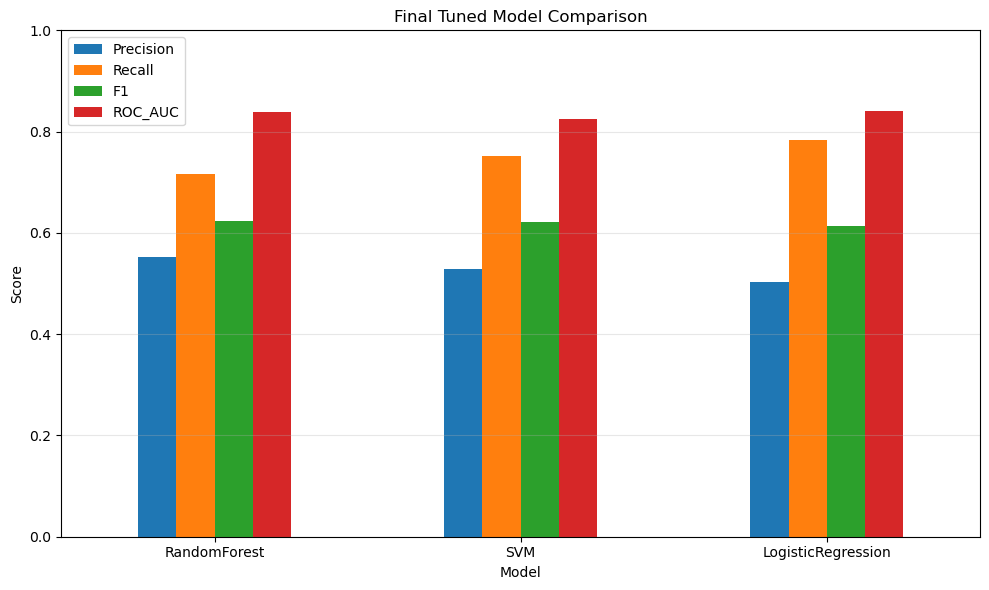

In [29]:
plot_df = results_df[["Model", "Precision", "Recall", "F1", "ROC_AUC"]].set_index("Model")

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Final Tuned Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

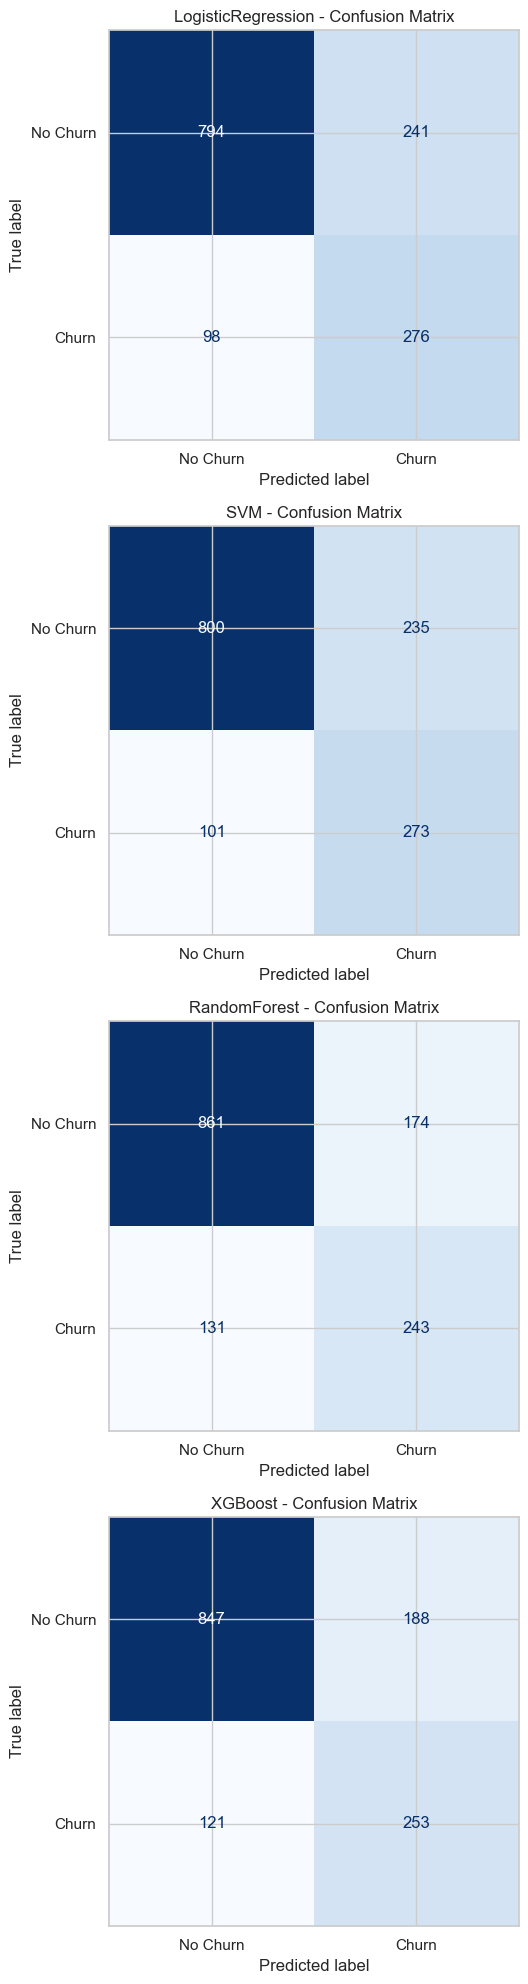

In [34]:
n_models = len(artifacts)
fig, axes = plt.subplots(n_models, 1, figsize=(6, 5 * n_models))

if n_models == 1:
    axes = [axes]

for ax, (model_name, values) in zip(axes, artifacts.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=values["confusion_matrix"],
        display_labels=["No Churn", "Churn"],
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{model_name} - Confusion Matrix")

plt.tight_layout()
plt.show()

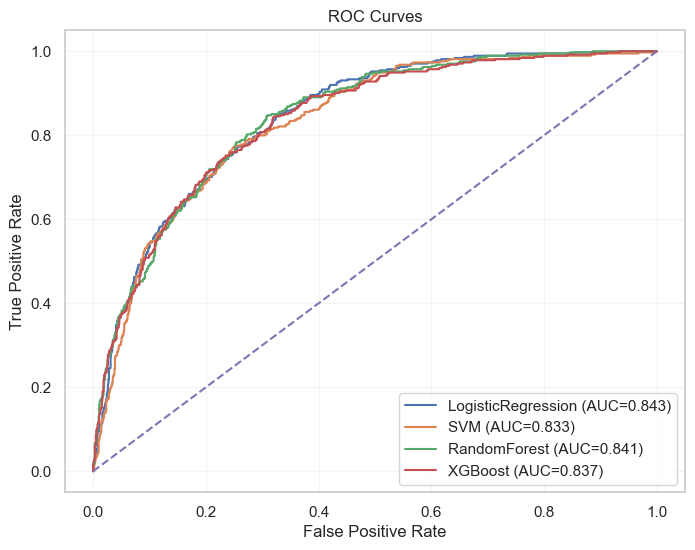

In [38]:
plt.figure(figsize=(8, 6))

for model_name, values in artifacts.items():
    roc_auc = auc(values["fpr"], values["tpr"])
    plt.plot(values["fpr"], values["tpr"], label=f"{model_name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [47]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

perm = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1",
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "ImportanceMean": perm.importances_mean,
    "ImportanceStd": perm.importances_std,
}).sort_values(by="ImportanceMean", ascending=False)

importance_df.head(15)

,Feature,ImportanceMean,ImportanceStd
14,Contract,0.112016,0.012453
4,tenure,0.053726,0.010483
7,InternetService,0.021631,0.007328
18,TotalCharges,0.016436,0.007883
19,AvgChargesPerMonth,0.012131,0.011637
8,OnlineSecurity,0.007902,0.004706
12,StreamingTV,0.007676,0.002723
17,MonthlyCharges,0.007507,0.006101
16,PaymentMethod,0.005941,0.006214
11,TechSupport,0.004775,0.006967


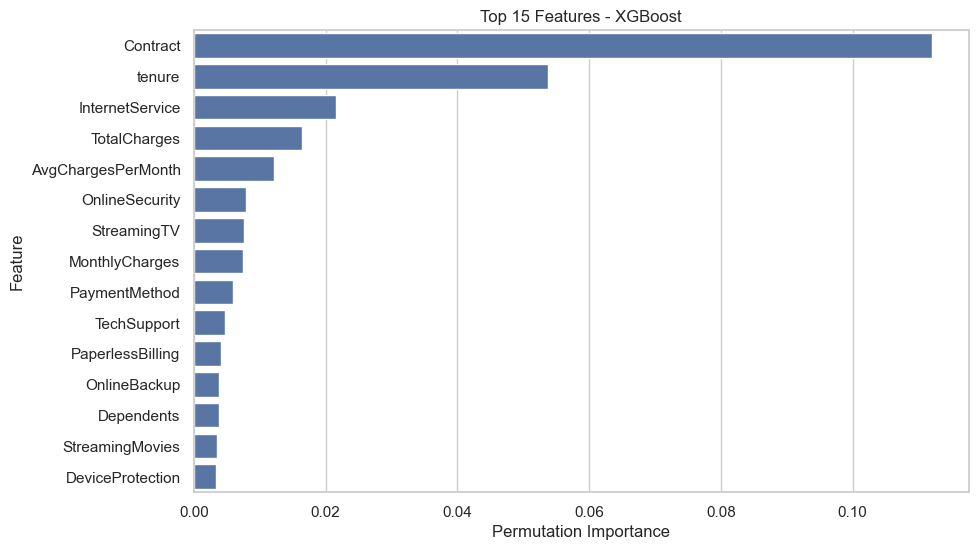

In [48]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="ImportanceMean", y="Feature")
plt.title(f"Top 15 Features - {best_model_name}")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.show()

In [10]:
df.shape

(7032, 20)

In [11]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [49]:
from sklearn.preprocessing import OneHotEncoder

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Preprocessing transformers
numeric_transformer = StandardScaler()

# One-hot encode categorical variables
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print("Preprocessor defined.")

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical features: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']
Preprocessor defined.


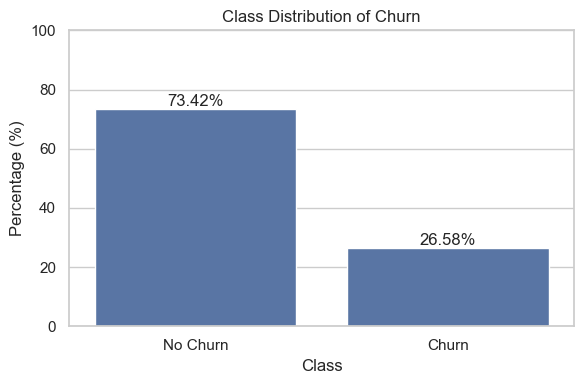

In [36]:
churn_dist = df['Churn'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
sns.barplot(x=churn_dist.index, y=churn_dist.values)
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.ylabel('Percentage (%)')
plt.xlabel('Class')
plt.title('Class Distribution of Churn')
plt.ylim(0, 100)

for i, v in enumerate(churn_dist.values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.tight_layout()
plt.show()

In [13]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (5625, 19) Test shape: (1407, 19)


In [14]:
print("y_train distribution:")
print(y_train.value_counts(normalize=True))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

y_train distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

y_test distribution:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [16]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = None
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min()) if scores.max() != scores.min() else None

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='binary'
    )

    print(f"\n=== {name} ===")
    print("Confusion matrix:\n", cm)
    print("Accuracy:", acc)
    print("Classification report:\n", classification_report(y_test, y_pred))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

    auc = None
    if y_proba is not None:
        auc = roc_auc_score(y_test, y_proba)
        print("ROC-AUC:", auc)

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend(loc="lower right")
        plt.show()

    metrics = {
        'model': name,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': auc
    }

    return metrics


=== Logistic Regression (SMOTE) ===
Confusion matrix:
 [[741 292]
 [ 84 290]]
Accuracy: 0.7327647476901208
Classification report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



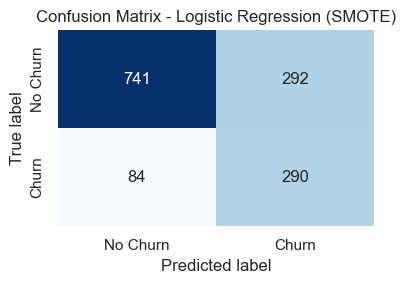

ROC-AUC: 0.8332060713046989


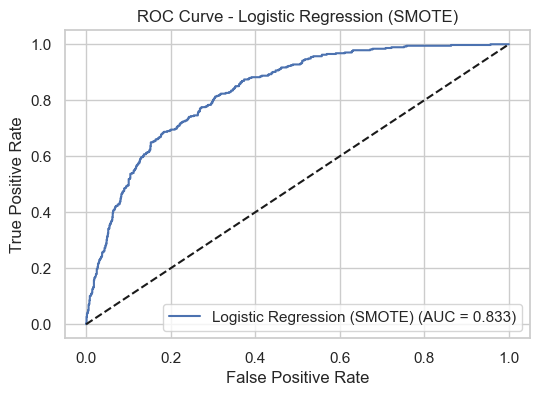

In [18]:
results = []

log_reg = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

log_reg.fit(X_train, y_train)

metrics_log_reg = evaluate_model("Logistic Regression (SMOTE)", log_reg, X_test, y_test)
results.append(metrics_log_reg)


=== Random Forest (SMOTE) ===
Confusion matrix:
 [[875 158]
 [158 216]]
Accuracy: 0.775408670931059
Classification report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.58      0.58      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.78      0.78      0.78      1407



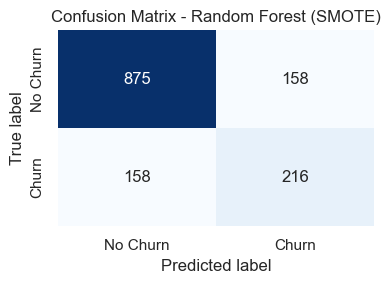

ROC-AUC: 0.8175877849159552


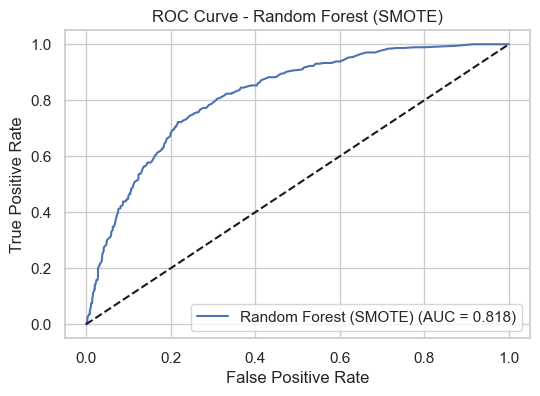

In [20]:
# 2. Random Forest with SMOTE

rf_clf = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_clf.fit(X_train, y_train)

metrics_rf = evaluate_model("Random Forest (SMOTE)", rf_clf, X_test, y_test)
results.append(metrics_rf)

In [37]:
from sklearn.model_selection import RandomizedSearchCV

In [38]:
# Random Forest tuning

rf_tune_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42))
])

rf_param_dist = {
    'clf__n_estimators': [100, 200, 300, 500],
    'clf__max_depth': [None, 5, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2', None]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_tune_pipeline,
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_random_search.best_params_)

print("\nBest Random Forest ROC-AUC:")
print(rf_random_search.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Random Forest parameters:
{'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 2, 'clf__max_features': 'log2', 'clf__max_depth': 10}

Best Random Forest ROC-AUC:
0.8434316972636797



=== Random Forest Tuned (SMOTE) ===
Confusion matrix:
 [[813 220]
 [108 266]]
Accuracy: 0.7668798862828714
Classification report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.83      1033
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.79      0.77      0.78      1407



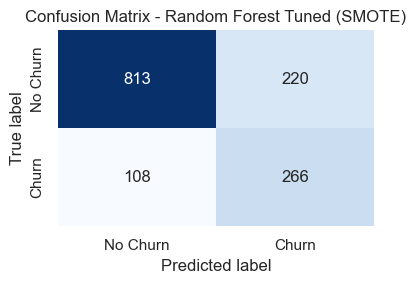

ROC-AUC: 0.8344251983993456


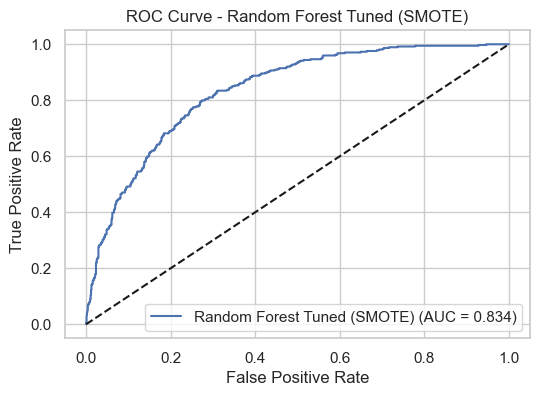

In [40]:
best_rf_model = rf_random_search.best_estimator_

metrics_rf_tuned = evaluate_model(
    "Random Forest Tuned (SMOTE)",
    best_rf_model,
    X_test,
    y_test
)

results.append(metrics_rf_tuned)


=== SVM (RBF, SMOTE) ===
Confusion matrix:
 [[772 261]
 [ 94 280]]
Accuracy: 0.7476901208244492
Classification report:
               precision    recall  f1-score   support

           0       0.89      0.75      0.81      1033
           1       0.52      0.75      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407



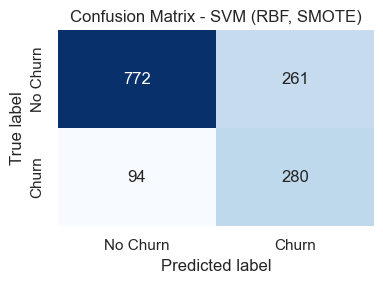

ROC-AUC: 0.810738930791889


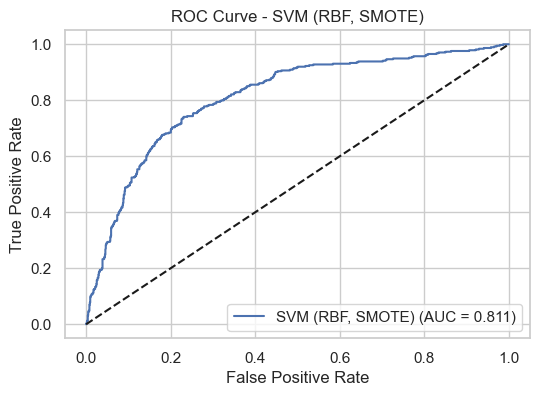

In [21]:
# 3. Support Vector Machine (SVM) with SMOTE

svm_clf = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC(kernel='rbf', probability=True, random_state=42))
])

svm_clf.fit(X_train, y_train)

metrics_svm = evaluate_model("SVM (RBF, SMOTE)", svm_clf, X_test, y_test)
results.append(metrics_svm)


=== XGBoost (SMOTE) ===
Confusion matrix:
 [[862 171]
 [143 231]]
Accuracy: 0.7768301350390903
Classification report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.85      1033
           1       0.57      0.62      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.78      0.78      0.78      1407



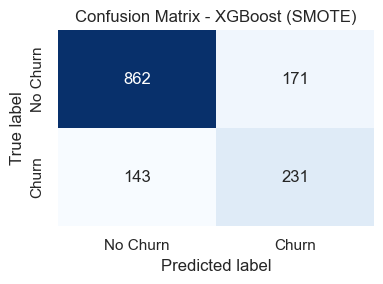

ROC-AUC: 0.8310460679915722


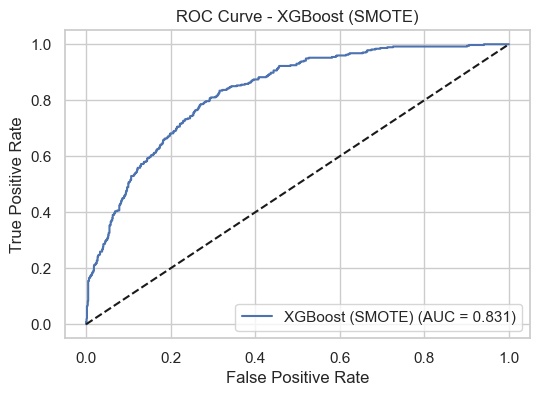

In [22]:
# 4. XGBoost (if available) with SMOTE

if xgb_available:
    xgb_clf = ImbPipeline(steps=[
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42
        ))
    ])

    xgb_clf.fit(X_train, y_train)

    metrics_xgb = evaluate_model("XGBoost (SMOTE)", xgb_clf, X_test, y_test)
    results.append(metrics_xgb)
else:
    print("XGBoost is not installed. Install it with 'pip install xgboost' to run this cell.")

In [41]:
# XGBoost tuning

if xgb_available:
    xgb_tune_pipeline = ImbPipeline(steps=[
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42
        ))
    ])

    xgb_param_dist = {
        'clf__n_estimators': [100, 200, 300, 500],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'clf__max_depth': [3, 4, 5, 6],
        'clf__subsample': [0.7, 0.8, 0.9, 1.0],
        'clf__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'clf__gamma': [0, 0.1, 0.3, 0.5]
    }

    xgb_random_search = RandomizedSearchCV(
        estimator=xgb_tune_pipeline,
        param_distributions=xgb_param_dist,
        n_iter=15,
        scoring='roc_auc',
        cv=5,
        verbose=2,
        random_state=42,
        n_jobs=-1
    )

    xgb_random_search.fit(X_train, y_train)

    print("Best XGBoost parameters:")
    print(xgb_random_search.best_params_)

    print("\nBest XGBoost ROC-AUC:")
    print(xgb_random_search.best_score_)
else:
    print("XGBoost is not available.")

Fitting 5 folds for each of 15 candidates, totalling 75 fits


C:\Users\user\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best XGBoost parameters:
{'clf__subsample': 0.9, 'clf__n_estimators': 200, 'clf__max_depth': 5, 'clf__learning_rate': 0.05, 'clf__gamma': 0, 'clf__colsample_bytree': 1.0}

Best XGBoost ROC-AUC:
nan



=== XGBoost Tuned (SMOTE) ===
Confusion matrix:
 [[858 175]
 [134 240]]
Accuracy: 0.7803837953091685
Classification report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.85      1033
           1       0.58      0.64      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407



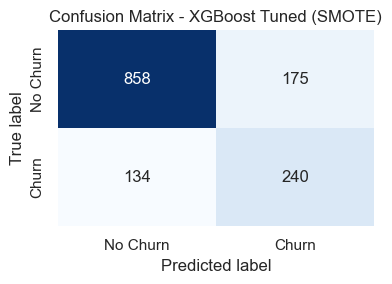

ROC-AUC: 0.833096065144354


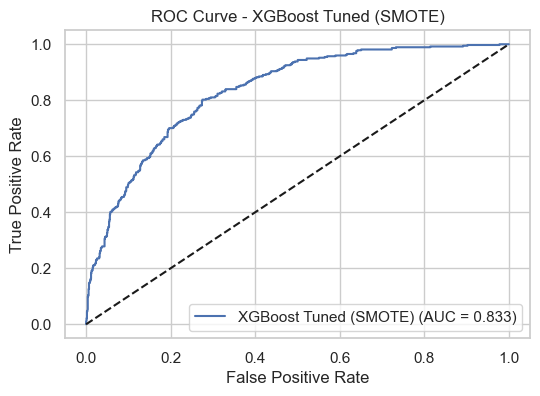

In [42]:
if xgb_available:
    best_xgb_model = xgb_random_search.best_estimator_

    metrics_xgb_tuned = evaluate_model(
        "XGBoost Tuned (SMOTE)",
        best_xgb_model,
        X_test,
        y_test
    )

    results.append(metrics_xgb_tuned)

In [43]:
results_df = pd.DataFrame(results)
results_df.sort_values(by='roc_auc', ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
6,Random Forest Tuned (SMOTE),0.766880,0.547325,0.711230,0.618605,0.834425
5,Random Forest Tuned (SMOTE),0.766880,0.547325,0.711230,0.618605,0.834425
0,Logistic Regression (SMOTE),0.732765,0.498282,0.775401,0.606695,0.833206
7,XGBoost Tuned (SMOTE),0.780384,0.578313,0.641711,0.608365,0.833096
4,XGBoost (SMOTE),0.776830,0.574627,0.617647,0.595361,0.831046
1,Random Forest (SMOTE),0.775409,0.577540,0.577540,0.577540,0.817588
2,Random Forest (SMOTE),0.775409,0.577540,0.577540,0.577540,0.817588
3,"SVM (RBF, SMOTE)",0.747690,0.517560,0.748663,0.612022,0.810739


In [44]:
# Model comparison diagrams (metrics across models)

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (SMOTE),0.732765,0.498282,0.775401,0.606695,0.833206
1,Random Forest (SMOTE),0.775409,0.577540,0.577540,0.577540,0.817588
2,Random Forest (SMOTE),0.775409,0.577540,0.577540,0.577540,0.817588
3,"SVM (RBF, SMOTE)",0.747690,0.517560,0.748663,0.612022,0.810739
4,XGBoost (SMOTE),0.776830,0.574627,0.617647,0.595361,0.831046
5,Random Forest Tuned (SMOTE),0.766880,0.547325,0.711230,0.618605,0.834425
6,Random Forest Tuned (SMOTE),0.766880,0.547325,0.711230,0.618605,0.834425
7,XGBoost Tuned (SMOTE),0.780384,0.578313,0.641711,0.608365,0.833096


In [45]:
results_df.sort_values(by="roc_auc", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
6,Random Forest Tuned (SMOTE),0.766880,0.547325,0.711230,0.618605,0.834425
5,Random Forest Tuned (SMOTE),0.766880,0.547325,0.711230,0.618605,0.834425
0,Logistic Regression (SMOTE),0.732765,0.498282,0.775401,0.606695,0.833206
7,XGBoost Tuned (SMOTE),0.780384,0.578313,0.641711,0.608365,0.833096
4,XGBoost (SMOTE),0.776830,0.574627,0.617647,0.595361,0.831046
1,Random Forest (SMOTE),0.775409,0.577540,0.577540,0.577540,0.817588
2,Random Forest (SMOTE),0.775409,0.577540,0.577540,0.577540,0.817588
3,"SVM (RBF, SMOTE)",0.747690,0.517560,0.748663,0.612022,0.810739


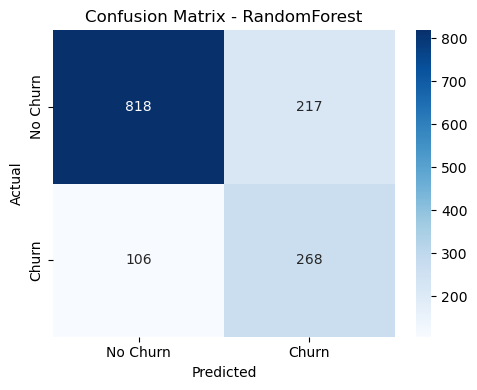

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

best_model_name = results_df.iloc[0]["Model"]
best_model = best_estimators[best_model_name]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

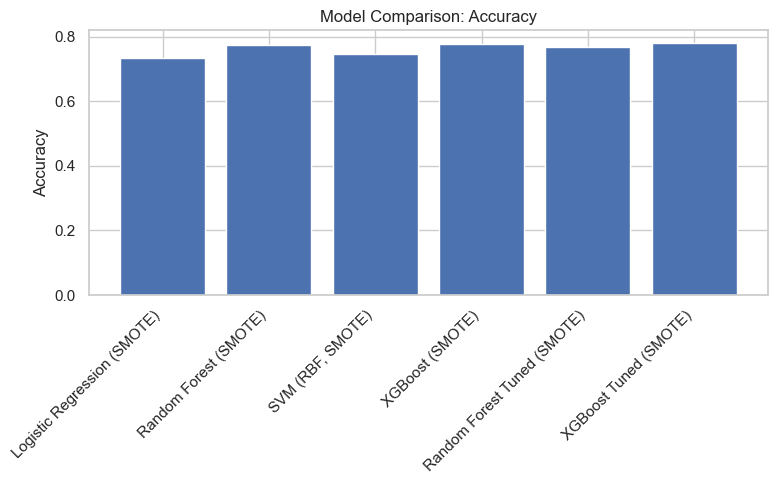

In [46]:
plt.figure(figsize=(8, 5))
plt.bar(results_df['model'], results_df['accuracy'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Model Comparison: Accuracy')
plt.tight_layout()
plt.show()

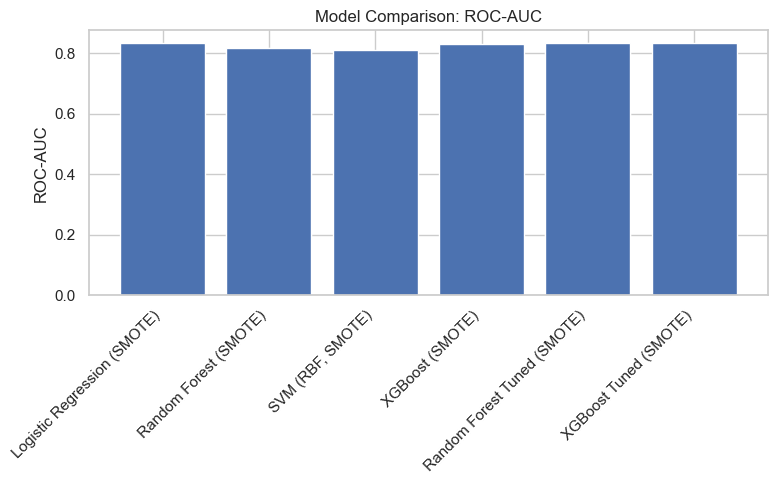

In [47]:
roc_df = results_df.dropna(subset=['roc_auc'])

plt.figure(figsize=(8, 5))
plt.bar(roc_df['model'], roc_df['roc_auc'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('ROC-AUC')
plt.title('Model Comparison: ROC-AUC')
plt.tight_layout()
plt.show()

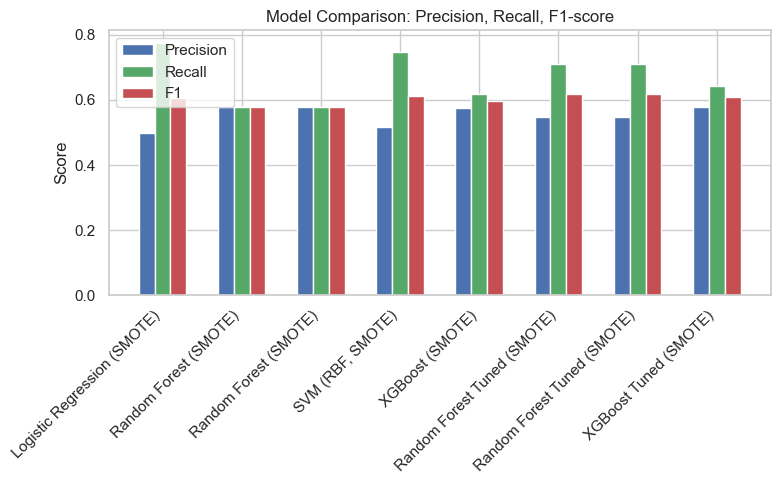

In [48]:
# Bar charts: Precision, Recall, F1-score per model

metrics_to_plot = ['precision', 'recall', 'f1']
colors = ['#4c72b0', '#55a868', '#c44e52']

plt.figure(figsize=(8, 5))
bar_width = 0.2
indices = np.arange(len(results_df['model']))

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    plt.bar(indices + i * bar_width, results_df[metric],
            width=bar_width, color=color, label=metric.capitalize())

plt.xticks(indices + bar_width, results_df['model'], rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Model Comparison: Precision, Recall, F1-score')
plt.legend()
plt.tight_layout()
plt.show()

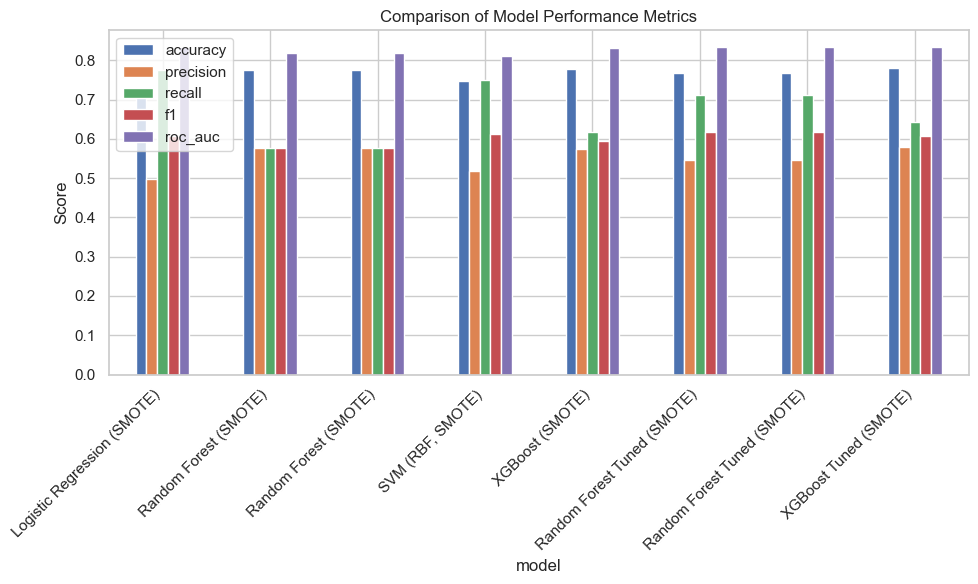

In [49]:
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results_df.set_index('model')[metrics_to_plot].plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (SMOTE),0.732765,0.498282,0.775401,0.606695,0.833206
1,Random Forest (SMOTE),0.775409,0.577540,0.577540,0.577540,0.817588
2,Random Forest (SMOTE),0.775409,0.577540,0.577540,0.577540,0.817588
3,"SVM (RBF, SMOTE)",0.747690,0.517560,0.748663,0.612022,0.810739
4,XGBoost (SMOTE),0.776830,0.574627,0.617647,0.595361,0.831046


In [50]:
# Feature importance using Random Forest on one-hot encoded data

# For feature importance we need explicit one-hot encoded feature names
X_encoded = pd.get_dummies(X, drop_first=True)

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

rf_for_imp = RandomForestClassifier(n_estimators=300, random_state=42)
rf_for_imp.fit(X_train_enc, y_train_enc)

importances = rf_for_imp.feature_importances_
feature_importance = pd.Series(importances, index=X_encoded.columns).sort_values(ascending=False)

print("Top 20 most important features for churn prediction:")
feature_importance.head(20)

Top 20 most important features for churn prediction:


TotalCharges                             0.193238
tenure                                   0.170365
MonthlyCharges                           0.168902
InternetService_Fiber optic              0.038595
PaymentMethod_Electronic check           0.037837
Contract_Two year                        0.032238
gender_Male                              0.028753
OnlineSecurity_Yes                       0.027205
PaperlessBilling_Yes                     0.025457
Partner_Yes                              0.023462
Contract_One year                        0.022874
TechSupport_Yes                          0.022659
OnlineBackup_Yes                         0.022333
SeniorCitizen                            0.021001
Dependents_Yes                           0.020104
MultipleLines_Yes                        0.019827
DeviceProtection_Yes                     0.018971
StreamingMovies_Yes                      0.017321
StreamingTV_Yes                          0.017025
PaymentMethod_Credit card (automatic)    0.013425


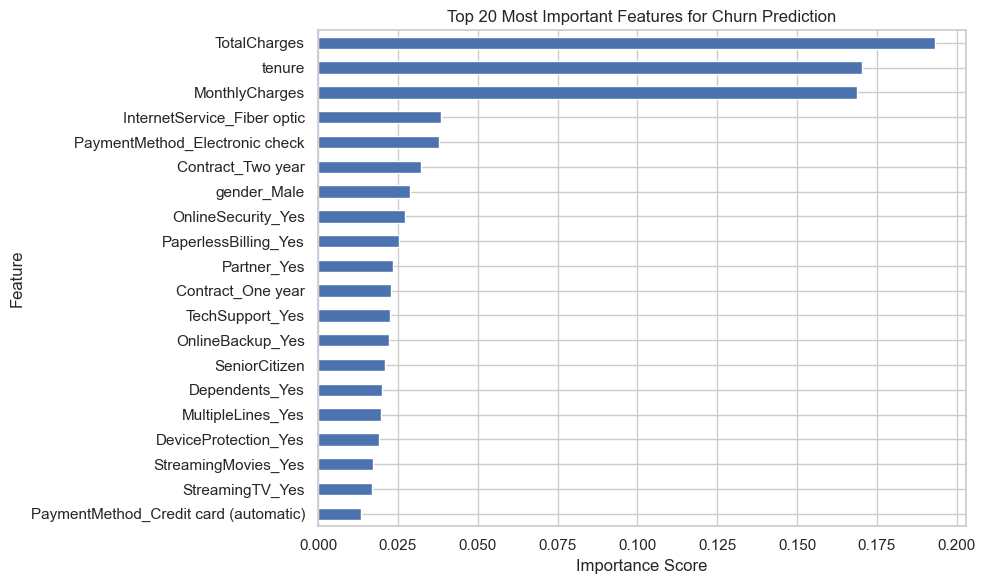

In [52]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind='barh')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 20 Most Important Features for Churn Prediction')
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [25]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [26]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [27]:
X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
rf_for_imp = RandomForestClassifier(n_estimators=300, random_state=42)
rf_for_imp.fit(X_train_enc, y_train_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
print(results_df.iloc[0]["Model"])

RandomForest


In [54]:
import shap
import pandas as pd

best_model_name = results_df.iloc[0]["Model"]
best_model = best_estimators[best_model_name]

print("Best model:", best_model_name)

preprocessor_fitted = best_model.named_steps["preprocess"]
clf = best_model.named_steps["model"]

X_test_enc = preprocessor_fitted.transform(X_test)
feature_names = preprocessor_fitted.get_feature_names_out()
X_test_enc_df = pd.DataFrame(X_test_enc, columns=feature_names)

explainer = shap.Explainer(clf, X_test_enc_df)
shap_exp = explainer(X_test_enc_df)

print(type(shap_exp))
print(X_test_enc_df.shape)
print(shap_exp.values.shape)

Best model: RandomForest


100%|===================| 2809/2818 [01:32<00:00]        

<class 'shap._explanation.Explanation'>
(1409, 50)
(1409, 50, 2)


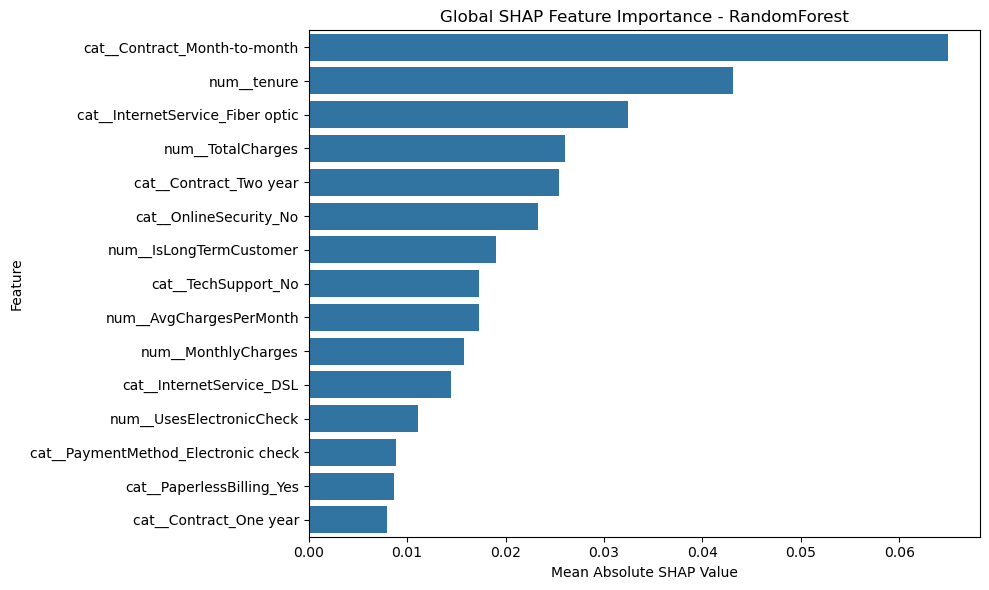

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# get SHAP values matrix
shap_matrix = shap_exp.values

# if SHAP returns 3D output, select the positive-class / main output safely
if len(shap_matrix.shape) == 3:
    shap_matrix = shap_matrix[:, :, 1]

# make sure feature count matches
n_features = min(shap_matrix.shape[1], len(feature_names), X_test_enc_df.shape[1])

shap_importance_df = pd.DataFrame({
    "Feature": feature_names[:n_features],
    "MeanAbsSHAP": np.abs(shap_matrix[:, :n_features]).mean(axis=0)
}).sort_values(by="MeanAbsSHAP", ascending=False)

top_shap = shap_importance_df.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_shap, x="MeanAbsSHAP", y="Feature")
plt.title(f"Global SHAP Feature Importance - {best_model_name}")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

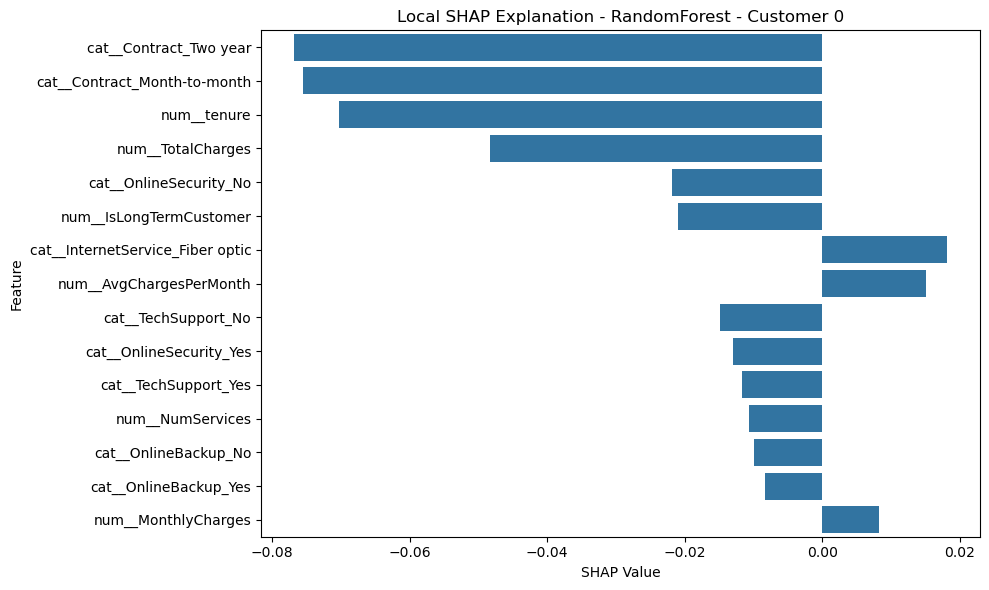

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sample_index = 0

local_shap = shap_exp.values[sample_index]

# if 2D for one sample with outputs, keep positive class
if len(local_shap.shape) == 2:
    local_shap = local_shap[:, 1]

n_features = min(len(local_shap), len(feature_names))

local_df = pd.DataFrame({
    "Feature": feature_names[:n_features],
    "SHAPValue": local_shap[:n_features]
})

local_df["AbsSHAP"] = np.abs(local_df["SHAPValue"])
local_top = local_df.sort_values(by="AbsSHAP", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=local_top, x="SHAPValue", y="Feature")
plt.title(f"Local SHAP Explanation - {best_model_name} - Customer {sample_index}")
plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

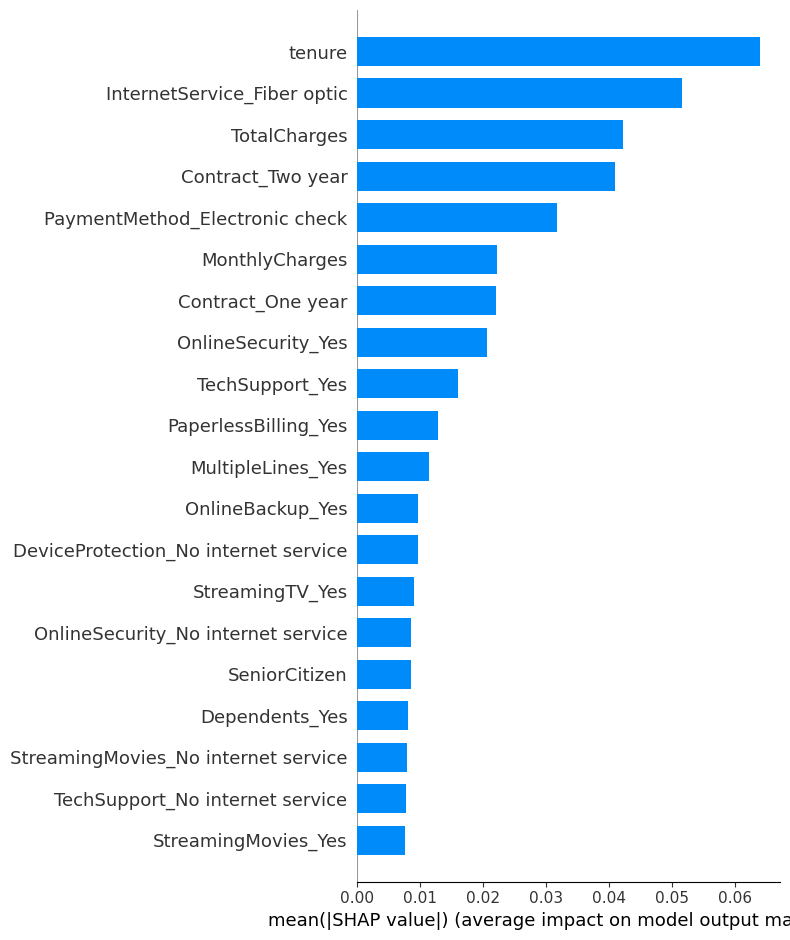

In [32]:
shap.summary_plot(shap_values[:, :, 1], X_test_enc, plot_type="bar")

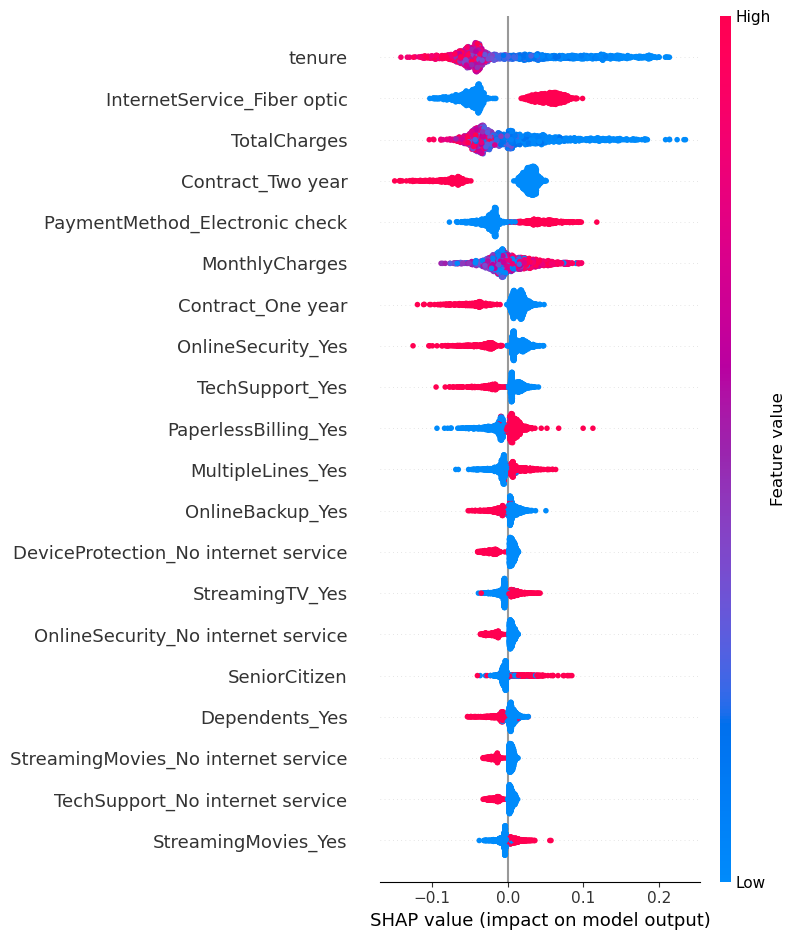

In [33]:
shap.summary_plot(shap_values[:, :, 1], X_test_enc)

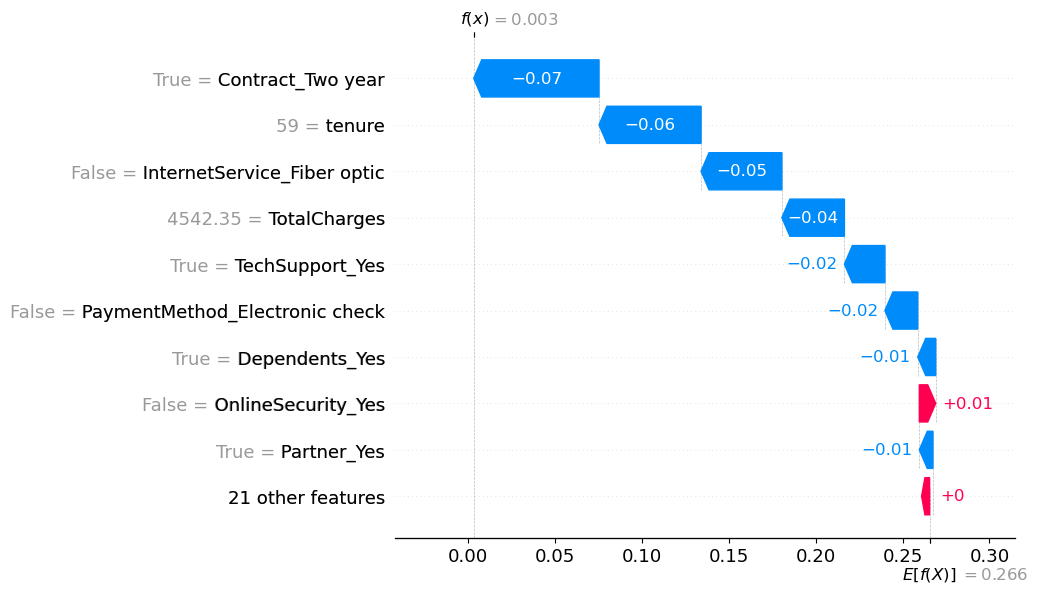

In [34]:
sample_idx = 0

if isinstance(shap_values, list):
    local_sv = shap_values[1][sample_idx]
    base_val = explainer.expected_value[1]
elif len(shap_values.shape) == 3:
    local_sv = shap_values[sample_idx, :, 1]
    base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    local_sv = shap_values[sample_idx]
    base_val = explainer.expected_value

shap.plots.waterfall(
    shap.Explanation(
        values=local_sv,
        base_values=base_val,
        data=X_test_enc.iloc[sample_idx],
        feature_names=X_test_enc.columns
    )
)